# Feature Selection: mRMR (Minimum Redundancy Maximum Relevance)

This notebook implements the professor's criterion:  
when selecting features, consider **both** the correlation of each feature  
with the target (PD vs CN) **and** the correlation with other selected features.

### The key insight

Suppose feature X has strong correlation with the target (high relevance)  
but also correlates with other features (high redundancy).  
Suppose feature Y has weak correlation with the target (low relevance)  
but is uncorrelated with everything (low redundancy).  

The **current approach** (greedy correlation pruning) might keep Y and drop X,  
because it only penalises redundancy without weighing relevance.

The **mRMR approach** keeps X because its predictive value outweighs the redundancy.  
It computes a score at each step:

$$\text{score}(X) = \text{relevance}(X, \text{target}) - \frac{1}{|S|} \sum_{j \in S} \text{redundancy}(X, j)$$

where $S$ is the set of already-selected features. The feature with the  
highest score gets added next.

---

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CHANGE THESE PATHS                                        ║
# ╚══════════════════════════════════════════════════════════════╝

#CYMO_CSV = '../ParkCeleb/ann.cymo_parkceleb.csv'
CYMO_CSV = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'

#META_CSV = '../ParkCeleb/cymo_parkceleb_metadata.csv'
META_CSV = './cymo_parkceleb_per_recording_metadata.csv'

N_SELECT = 20  # how many features to select

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
})
print('Imports OK')

Imports OK


In [3]:
# ============================================================
# 1.  Load and merge (same as before)
# ============================================================
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]
feature_cols = [c for c in cymo.columns if c != tid_col]

df = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)

# Clean features
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop >50% missing and zero-variance
missing_pct = df[feature_cols].isnull().sum() / len(df)
keep = missing_pct[missing_pct <= 0.5].index.tolist()
df[keep] = df[keep].fillna(df[keep].median())
variances = df[keep].var()
keep = [c for c in keep if variances[c] > 1e-10]
feature_cols = keep

print(f'Loaded: {len(df)} rows, {len(feature_cols)} usable features')
print(f'  CN: {(df["label"]==0).sum()}   PD: {(df["label"]==1).sum()}')

Loaded: 143818 rows, 345 usable features
  CN: 80129   PD: 63689


---
## 2 — Compute relevance and redundancy matrices

We need two things:
1. **Relevance:** how strongly each feature relates to the target (PD vs CN)
2. **Redundancy:** how strongly each feature relates to every other feature

For relevance, we'll use the **absolute Spearman correlation** with the binary label  
(and also mutual information as a second option).  
For redundancy, we'll use the **absolute Spearman correlation** between features.

In [4]:
# ============================================================
# 2.1  Relevance: correlation of each feature with the target
# ============================================================
y = df['label'].values

relevance = {}
for feat in feature_cols:
    rho, _ = stats.spearmanr(df[feat].values, y)
    relevance[feat] = abs(rho)  # absolute value — direction doesn't matter for selection

rel_series = pd.Series(relevance).sort_values(ascending=False)

print('Top 20 features by relevance (|Spearman ρ| with target):')
for i, (feat, val) in enumerate(rel_series.head(20).items()):
    bar = '█' * int(val * 80)
    print(f'  {i+1:>3d}. {feat:<40s} ρ={val:.4f}  {bar}')

Top 20 features by relevance (|Spearman ρ| with target):
    1. N2SLOb                                   ρ=0.2108  ████████████████
    2. N2SFWOb                                  ρ=0.2034  ████████████████
    3. NSLOb                                    ρ=0.1942  ███████████████
    4. NSFWOb                                   ρ=0.1807  ██████████████
    5. N2SNOb                                   ρ=0.1269  ██████████
    6. NSNOb                                    ρ=0.1204  █████████
    7. 1GNLFn                                   ρ=0.1010  ████████
    8. 1GNLFm                                   ρ=0.1005  ████████
    9. 1GNLFw                                   ρ=0.0998  ███████
   10. 1GNLFa                                   ρ=0.0998  ███████
   11. 1GNLFb                                   ρ=0.0997  ███████
   12. 1GNLFs                                   ρ=0.0987  ███████
   13. 1GNLFf                                   ρ=0.0971  ███████
   14. 1GNLFtv                               

In [5]:
# ============================================================
# 2.2  Redundancy matrix: pairwise Spearman correlation between features
# ============================================================
print('Computing pairwise feature correlations (this may take a moment)...')
corr_matrix = df[feature_cols].corr(method='spearman').abs()
# Set diagonal to 0 (a feature's correlation with itself is not redundancy)
#np.fill_diagonal(corr_matrix.values, 0)
corr_matrix = corr_matrix.mask(np.eye(len(corr_matrix), dtype=bool), 0)
print(f'Done. Matrix shape: {corr_matrix.shape}')

Computing pairwise feature correlations (this may take a moment)...
Done. Matrix shape: (345, 345)


---
## 3 — mRMR feature selection

### Algorithm
1. **First feature:** select the feature with the highest relevance to the target
2. **Each subsequent feature:** for each remaining candidate, compute:  
   $\text{score}(X) = \text{relevance}(X) - \frac{1}{|S|} \sum_{j \in S} |\text{corr}(X, j)|$  
   Select the candidate with the highest score
3. Repeat until we have the desired number of features

This naturally implements the professor's criterion:  
a feature is selected if it brings **new information about the target**  
that isn't already captured by previously selected features.

In [6]:
# ============================================================
# 3.1  mRMR implementation
# ============================================================

def mrmr_select(relevance_dict, corr_matrix, feature_list, n_select):
    """
    Minimum Redundancy Maximum Relevance feature selection.
    
    At each step, selects the feature that maximises:
        score = relevance(X, target) - mean(|corr(X, already_selected)|)
    
    Args:
        relevance_dict: {feature_name: relevance_score}
        corr_matrix: DataFrame of absolute pairwise correlations
        feature_list: list of candidate feature names
        n_select: number of features to select
    
    Returns:
        List of (feature_name, relevance, mean_redundancy, score) tuples
    """
    candidates = set(feature_list)
    selected = []
    selection_log = []
    
    for step in range(n_select):
        best_score = -np.inf
        best_feat = None
        best_rel = 0
        best_red = 0
        
        for feat in candidates:
            rel = relevance_dict.get(feat, 0)
            
            # Mean redundancy with already-selected features
            if len(selected) == 0:
                red = 0
            else:
                red = corr_matrix.loc[feat, [s[0] for s in selected]].mean()
            
            score = rel - red
            
            if score > best_score:
                best_score = score
                best_feat = feat
                best_rel = rel
                best_red = red
        
        if best_feat is None:
            break
        
        selected.append((best_feat, best_rel, best_red, best_score))
        candidates.remove(best_feat)
        selection_log.append({
            'step': step + 1,
            'feature': best_feat,
            'relevance': best_rel,
            'redundancy': best_red,
            'mrmr_score': best_score,
        })
    
    return selection_log


# Run mRMR
mrmr_log = mrmr_select(relevance, corr_matrix, feature_cols, N_SELECT)
mrmr_df = pd.DataFrame(mrmr_log)
mrmr_features = mrmr_df['feature'].tolist()

print(f'mRMR selected {len(mrmr_features)} features:\n')
print(f'{"Step":<5s} {"Feature":<40s} {"Relevance":>10s} {"Redundancy":>11s} {"mRMR Score":>11s}')
print('─' * 82)
for _, row in mrmr_df.iterrows():
    print(f'{row["step"]:<5.0f} {row["feature"]:<40s} '
          f'{row["relevance"]:>10.4f} {row["redundancy"]:>11.4f} {row["mrmr_score"]:>11.4f}')

mRMR selected 20 features:

Step  Feature                                   Relevance  Redundancy  mRMR Score
──────────────────────────────────────────────────────────────────────────────────
1     N2SLOb                                       0.2108      0.0000      0.2108
2     wid                                          0.0847      0.0317      0.0530
3     TOPspo                                       0.0833      0.0415      0.0418
4     T50KCOCAw                                    0.0809      0.0672      0.0137
5     DETposs1p                                    0.0472      0.0291      0.0182
6     TOPhea                                       0.0703      0.0555      0.0148
7     PRNposs2                                     0.0276      0.0196      0.0080
8     TOPpol                                       0.0607      0.0493      0.0114
9     NSLOb                                        0.1942      0.1806      0.0137
10    QUANTon                                      0.0303      0.0211

### How to read this table

- **Relevance** = how strongly this feature correlates with the PD/CN label
- **Redundancy** = average correlation with all previously selected features
- **mRMR Score** = relevance minus redundancy (higher = better tradeoff)

Notice that step 1 always selects the single most relevant feature (redundancy = 0).  
Later steps may select features with lower relevance if they bring non-redundant information.

---
## 4 — Compare: old approach vs mRMR

Let's run the old greedy correlation pruning approach and compare  
which features each method selects.

In [7]:
# ============================================================
# 4.1  Old approach: rank by effect size, greedy pruning at ρ>0.85
# ============================================================

# Rank by |Cohen's d|
cn_df = df[df['label'] == 0]
pd_df = df[df['label'] == 1]

effect_sizes = {}
for feat in feature_cols:
    cn = cn_df[feat].dropna()
    pd_v = pd_df[feat].dropna()
    n1, n2 = len(cn), len(pd_v)
    if n1 < 5 or n2 < 5:
        continue
    pooled = np.sqrt(((n1-1)*cn.var() + (n2-1)*pd_v.var()) / (n1+n2-2))
    d = abs((pd_v.mean() - cn.mean()) / pooled) if pooled > 0 else 0
    effect_sizes[feat] = d

ranked_by_d = sorted(effect_sizes.keys(), key=lambda x: effect_sizes[x], reverse=True)

# Greedy correlation pruning
CORR_THRESH = 0.85
old_selected = []

for feat in ranked_by_d:
    too_correlated = False
    for sel in old_selected:
        if corr_matrix.loc[feat, sel] > CORR_THRESH:
            too_correlated = True
            break
    if not too_correlated:
        old_selected.append(feat)
    if len(old_selected) >= N_SELECT:
        break

print(f'Old approach selected {len(old_selected)} features')
print(f'mRMR approach selected {len(mrmr_features)} features')

Old approach selected 20 features
mRMR approach selected 20 features


In [8]:
# ============================================================
# 4.2  Compare the two feature sets
# ============================================================
old_set = set(old_selected)
mrmr_set = set(mrmr_features)

shared = old_set & mrmr_set
only_old = old_set - mrmr_set
only_mrmr = mrmr_set - old_set

print(f'Comparison: Old Approach vs mRMR')
print(f'={"="*60}')
print(f'  Features in both       : {len(shared)}')
print(f'  Only in old approach   : {len(only_old)}')
print(f'  Only in mRMR           : {len(only_mrmr)}')
print(f'  Overlap (Jaccard)      : {len(shared) / len(old_set | mrmr_set):.1%}')

print(f'\n  Shared features ({len(shared)}):')
for f in sorted(shared):
    print(f'    ✓ {f}')

print(f'\n  Only in old approach ({len(only_old)}):')
for f in sorted(only_old):
    rel = relevance.get(f, 0)
    # Avg correlation with mRMR-selected features
    avg_corr = corr_matrix.loc[f, list(mrmr_set)].mean() if len(mrmr_set) > 0 else 0
    print(f'    ✗ {f:<40s}  relevance={rel:.4f}  avg_corr_with_mrmr={avg_corr:.3f}')

print(f'\n  Only in mRMR ({len(only_mrmr)}):')
for f in sorted(only_mrmr):
    rel = relevance.get(f, 0)
    avg_corr = corr_matrix.loc[f, list(old_set)].mean() if len(old_set) > 0 else 0
    print(f'    ★ {f:<40s}  relevance={rel:.4f}  avg_corr_with_old={avg_corr:.3f}')

Comparison: Old Approach vs mRMR
  Features in both       : 4
  Only in old approach   : 16
  Only in mRMR           : 16
  Overlap (Jaccard)      : 11.1%

  Shared features (4):
    ✓ DPCOCAanorm
    ✓ N2SLOb
    ✓ TOPspo
    ✓ wid

  Only in old approach (16):
    ✗ N2SAOb                                    relevance=0.0858  avg_corr_with_mrmr=0.085
    ✗ N2SPOb                                    relevance=0.0551  avg_corr_with_mrmr=0.152
    ✗ N2SVOb                                    relevance=0.0913  avg_corr_with_mrmr=0.144
    ✗ NNGSL                                     relevance=0.0034  avg_corr_with_mrmr=0.091
    ✗ RSCOCAa                                   relevance=0.0322  avg_corr_with_mrmr=0.112
    ✗ T10KCOCAa                                 relevance=0.0459  avg_corr_with_mrmr=0.081
    ✗ T10KCOCAs                                 relevance=0.0228  avg_corr_with_mrmr=0.068
    ✗ T20KCOCAa                                 relevance=0.0451  avg_corr_with_mrmr=0.074
    ✗ T20

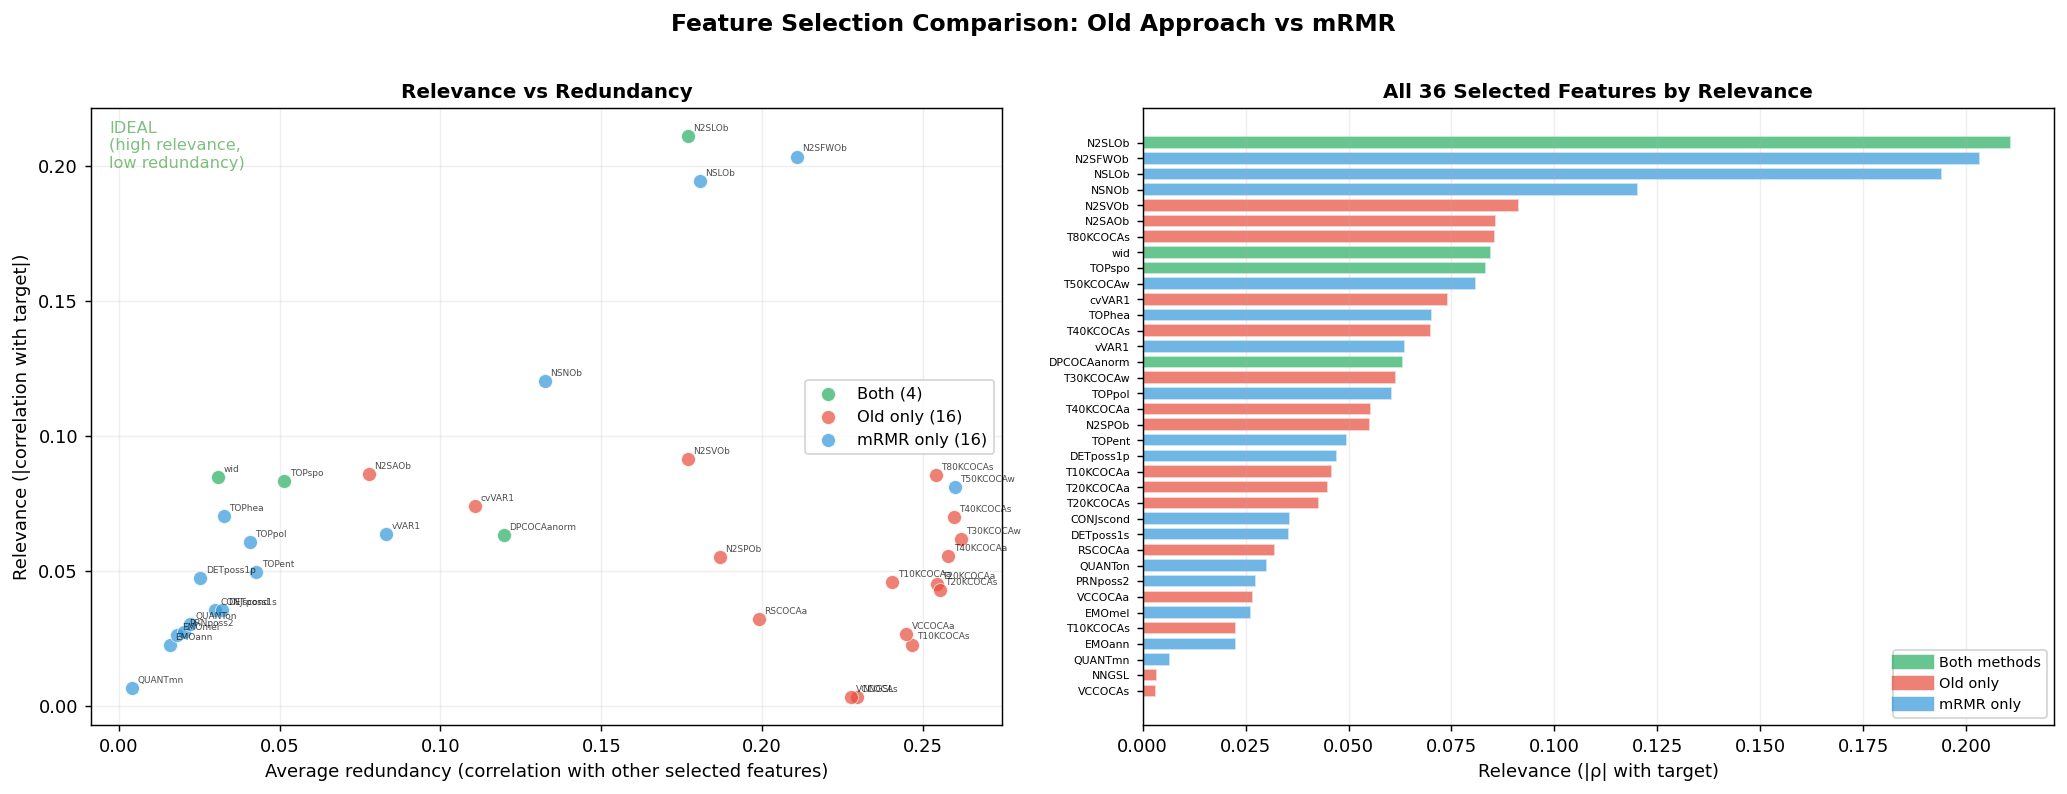

In [9]:
# ============================================================
# 4.3  Visualise the comparison
# ============================================================

# For each feature in both sets, show its relevance and avg redundancy
all_features_union = sorted(old_set | mrmr_set)

comparison_data = []
for feat in all_features_union:
    in_old = feat in old_set
    in_mrmr = feat in mrmr_set
    if in_old and in_mrmr:
        method = 'Both'
    elif in_old:
        method = 'Old only'
    else:
        method = 'mRMR only'
    
    rel = relevance.get(feat, 0)
    # Avg correlation with ALL other features in the union
    others = [f for f in all_features_union if f != feat]
    avg_red = corr_matrix.loc[feat, others].mean() if others else 0
    
    comparison_data.append({
        'feature': feat,
        'relevance': rel,
        'avg_redundancy': avg_red,
        'method': method,
    })

comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scatter plot of relevance vs redundancy
ax = axes[0]
colors_map = {'Both': '#27AE60', 'Old only': '#E74C3C', 'mRMR only': '#3498DB'}
for method, color in colors_map.items():
    subset = comp_df[comp_df['method'] == method]
    ax.scatter(subset['avg_redundancy'], subset['relevance'],
              c=color, s=60, alpha=0.7, label=f'{method} ({len(subset)})',
              edgecolors='white', linewidth=0.5)
    for _, row in subset.iterrows():
        ax.annotate(row['feature'], (row['avg_redundancy'], row['relevance']),
                   fontsize=5, alpha=0.7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Average redundancy (correlation with other selected features)')
ax.set_ylabel('Relevance (|correlation with target|)')
ax.set_title('Relevance vs Redundancy')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Ideal features are top-left: high relevance, low redundancy
ax.annotate('IDEAL\n(high relevance,\nlow redundancy)',
           xy=(0.02, 0.98), xycoords='axes fraction',
           fontsize=9, color='green', alpha=0.5,
           ha='left', va='top')

# Right: Side-by-side bar chart
ax = axes[1]
all_feats_sorted = sorted(all_features_union, key=lambda f: relevance.get(f, 0), reverse=True)
y_pos = range(len(all_feats_sorted))

bar_colors = []
for f in all_feats_sorted:
    if f in shared:
        bar_colors.append('#27AE60')
    elif f in only_old:
        bar_colors.append('#E74C3C')
    else:
        bar_colors.append('#3498DB')

ax.barh(y_pos, [relevance.get(f, 0) for f in all_feats_sorted],
        color=bar_colors, alpha=0.7, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(all_feats_sorted, fontsize=6)
ax.set_xlabel('Relevance (|ρ| with target)')
ax.set_title(f'All {len(all_feats_sorted)} Selected Features by Relevance')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2)

both_p = plt.Line2D([0], [0], color='#27AE60', lw=8, alpha=0.7, label='Both methods')
old_p = plt.Line2D([0], [0], color='#E74C3C', lw=8, alpha=0.7, label='Old only')
mrmr_p = plt.Line2D([0], [0], color='#3498DB', lw=8, alpha=0.7, label='mRMR only')
ax.legend(handles=[both_p, old_p, mrmr_p], fontsize=8, loc='lower right')

plt.suptitle('Feature Selection Comparison: Old Approach vs mRMR',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('mrmr_vs_old_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

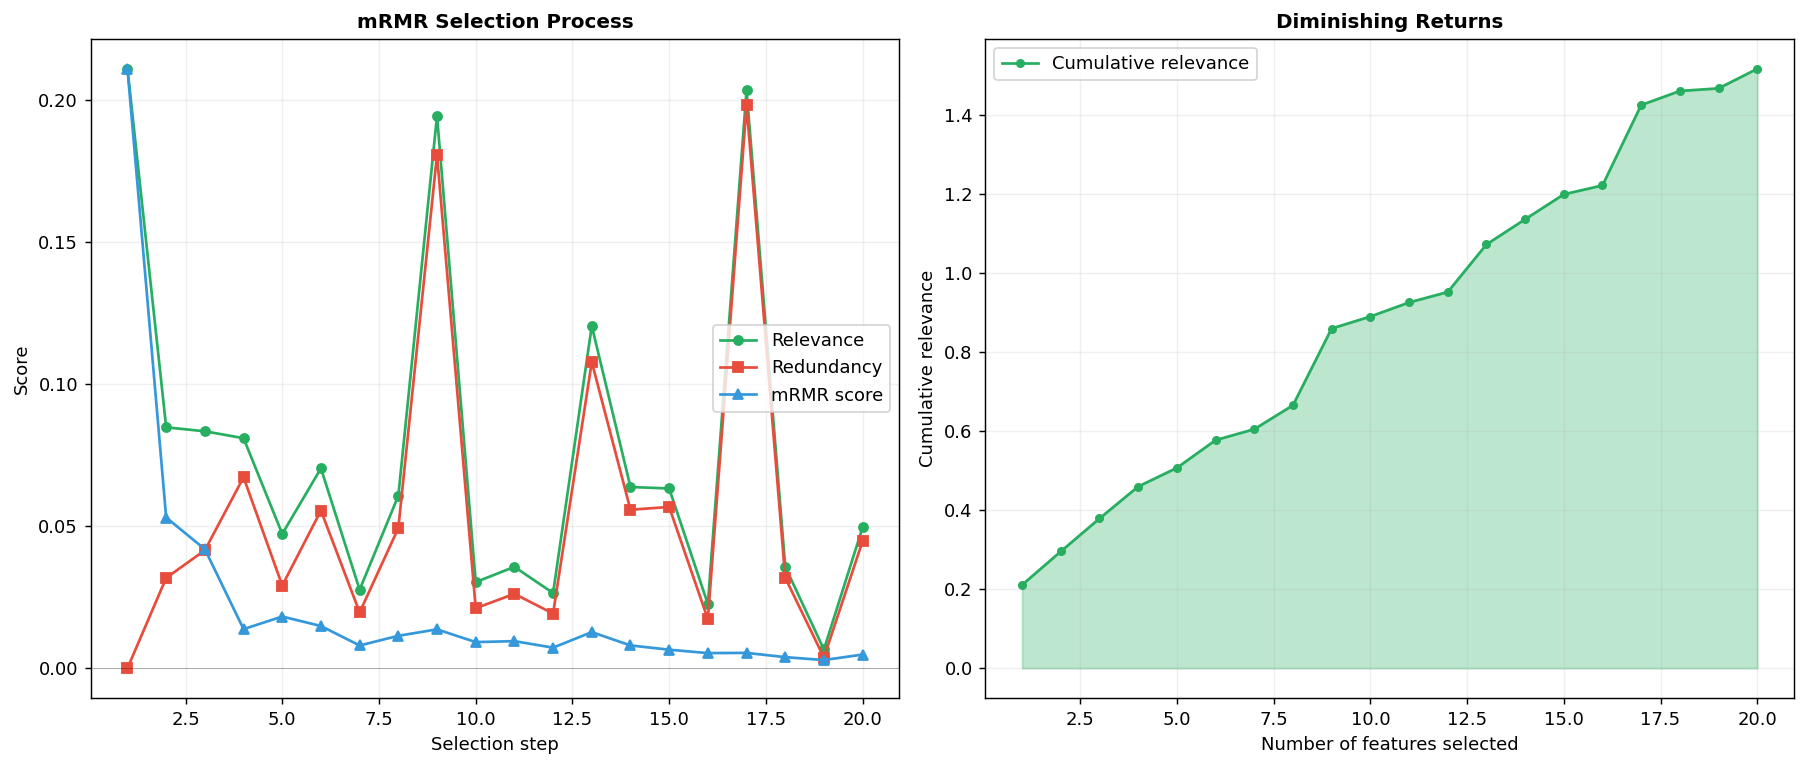

Notice how redundancy increases at each step (more features to overlap with)
and the mRMR score decreases. This is expected — later features add less new info.
The cumulative relevance plot shows diminishing returns after ~15-20 features.


In [10]:
# ============================================================
# 4.4  Show the mRMR selection process step by step
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: relevance and redundancy at each step
ax = axes[0]
ax.plot(mrmr_df['step'], mrmr_df['relevance'], 'o-', color='#27AE60',
        label='Relevance', markersize=5)
ax.plot(mrmr_df['step'], mrmr_df['redundancy'], 's-', color='#E74C3C',
        label='Redundancy', markersize=5)
ax.plot(mrmr_df['step'], mrmr_df['mrmr_score'], '^-', color='#3498DB',
        label='mRMR score', markersize=5)
ax.set_xlabel('Selection step')
ax.set_ylabel('Score')
ax.set_title('mRMR Selection Process')
ax.legend()
ax.grid(alpha=0.2)
ax.axhline(0, color='black', lw=0.5, alpha=0.3)

# Right: cumulative information gain
ax = axes[1]
cumulative_rel = mrmr_df['relevance'].cumsum()
ax.fill_between(mrmr_df['step'], 0, cumulative_rel, alpha=0.3, color='#27AE60')
ax.plot(mrmr_df['step'], cumulative_rel, 'o-', color='#27AE60',
        label='Cumulative relevance', markersize=4)
ax.set_xlabel('Number of features selected')
ax.set_ylabel('Cumulative relevance')
ax.set_title('Diminishing Returns')
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.savefig('mrmr_selection_process.png', dpi=150, bbox_inches='tight')
plt.show()

print('Notice how redundancy increases at each step (more features to overlap with)')
print('and the mRMR score decreases. This is expected — later features add less new info.')
print('The cumulative relevance plot shows diminishing returns after ~15-20 features.')

---
## 5 — Correlation matrices for both approaches

Let's see if the mRMR features are less correlated with each other  
than the old approach's features.

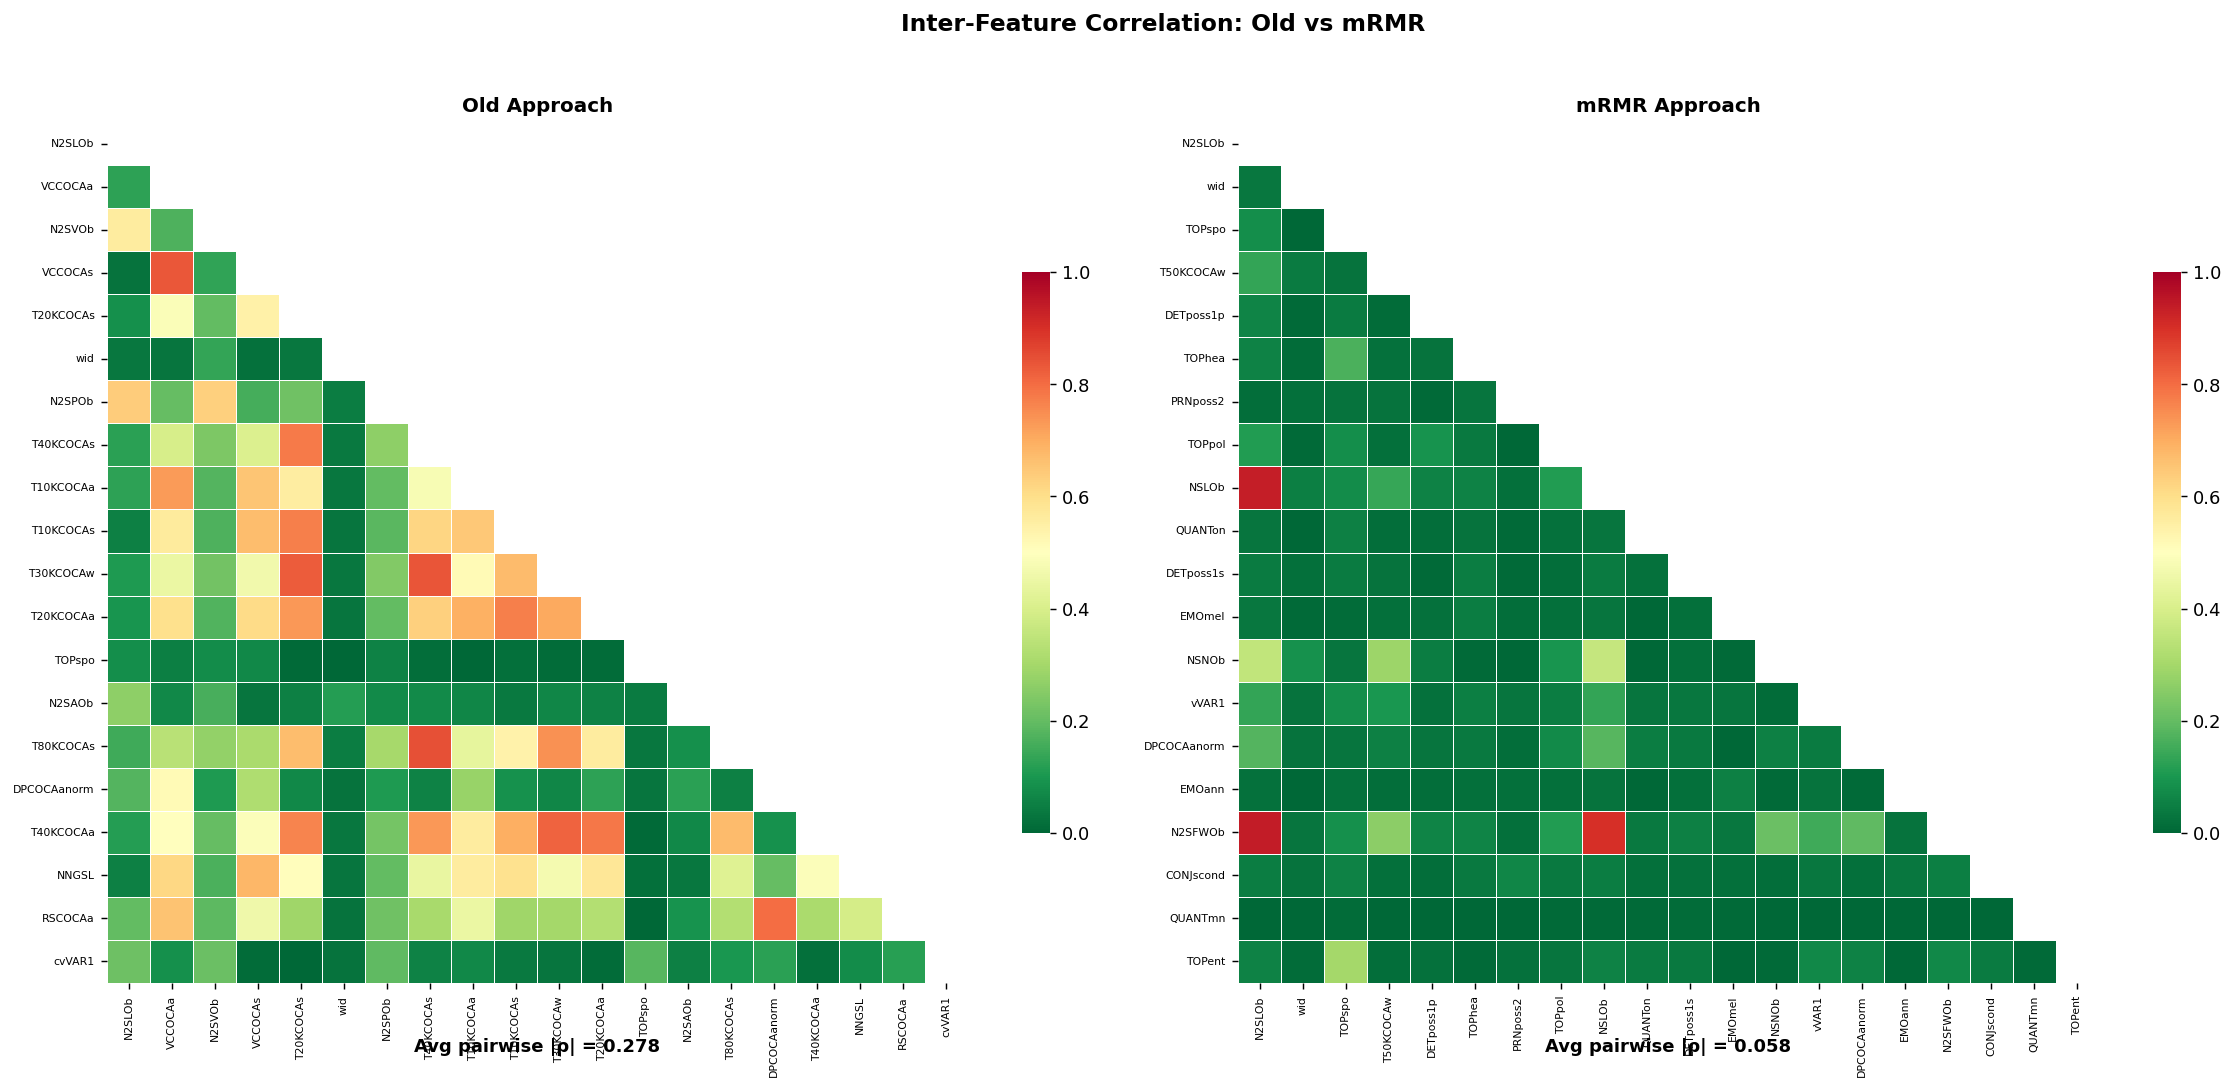

Lower average pairwise correlation = less redundancy in the feature set.
mRMR should show lower inter-feature correlation while maintaining relevance.


In [11]:
# ============================================================
# 5.  Side-by-side correlation matrices
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, feats, title in [
    (axes[0], old_selected, 'Old Approach'),
    (axes[1], mrmr_features, 'mRMR Approach'),
]:
    corr = df[feats].corr(method='spearman').abs()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='RdYlGn_r', center=0.5,
                vmin=0, vmax=1, square=True, linewidths=0.3,
                xticklabels=True, yticklabels=True, ax=ax,
                cbar_kws={'shrink': 0.6})
    ax.set_title(title)
    ax.tick_params(axis='both', labelsize=6)
    
    # Compute average off-diagonal correlation
    #np.fill_diagonal(corr.values, 0)
    #avg_corr = corr.values[np.triu_indices_from(corr.values, k=1)].mean()
    corr_arr = corr.to_numpy()
    avg_corr = corr_arr[np.triu_indices_from(corr_arr, k=1)].mean()
    ax.text(0.5, -0.08, f'Avg pairwise |ρ| = {avg_corr:.3f}',
            transform=ax.transAxes, ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Inter-Feature Correlation: Old vs mRMR',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('mrmr_correlation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lower average pairwise correlation = less redundancy in the feature set.')
print('mRMR should show lower inter-feature correlation while maintaining relevance.')

---
## 6 — Save mRMR results

In [12]:
# ============================================================
# 6.  Save
# ============================================================

# mRMR selection log
mrmr_df.to_csv('mrmr_selection_log.csv', index=False)
print(f'Saved: mrmr_selection_log.csv ({len(mrmr_df)} features)')

# mRMR feature list
pd.DataFrame({'feature': mrmr_features}).to_csv('mrmr_selected_features.csv', index=False)
print(f'Saved: mrmr_selected_features.csv')

# Dataset with only mRMR features
out_cols = [tid_col, 'group', 'subject', 'label'] + mrmr_features
out_cols = [c for c in out_cols if c in df.columns]
df[out_cols].to_csv('cymo_mrmr_features_data.csv', index=False)
print(f'Saved: cymo_mrmr_features_data.csv ({len(df)} rows × {len(out_cols)} cols)')

# Comparison summary
print(f'\n{"="*60}')
print(f'FINAL SUMMARY')
print(f'{"="*60}')
print(f'  Old approach : {len(old_selected)} features, avg pairwise |ρ| = '
      f'{df[old_selected].corr(method="spearman").abs().values[np.triu_indices(len(old_selected), k=1)].mean():.3f}')
print(f'  mRMR approach: {len(mrmr_features)} features, avg pairwise |ρ| = '
      f'{df[mrmr_features].corr(method="spearman").abs().values[np.triu_indices(len(mrmr_features), k=1)].mean():.3f}')
print(f'  Overlap      : {len(shared)}/{N_SELECT} features in common')
print(f'\n  → Use cymo_mrmr_features_data.csv for model training')

Saved: mrmr_selection_log.csv (20 features)
Saved: mrmr_selected_features.csv
Saved: cymo_mrmr_features_data.csv (143818 rows × 24 cols)

FINAL SUMMARY
  Old approach : 20 features, avg pairwise |ρ| = 0.278
  mRMR approach: 20 features, avg pairwise |ρ| = 0.058
  Overlap      : 4/20 features in common

  → Use cymo_mrmr_features_data.csv for model training
